In [1]:
!date

Fri Sep 18 00:26:50 PDT 2026


In [2]:
import glob
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
bedtools = '/u/home/t/terencew/bin/bedtools'
figdir = f'{projdir}/figures/pmds'
outdir = f'{projdir}/results/qc/data/qc12'
!mkdir -p {figdir} {outdir}

### donor covariates

In [4]:
chem = pd.read_csv(f'{projdir}/results/qc/data/supp_seq_qc.csv').set_index('sample_id')['sequencing_chemistry_ont']
summ = pd.concat([pd.read_csv(f, sep='\t') for f in glob.glob(f'{projdir}/results/meth_bins/per_hap/*.summary.tsv')])
summ['chemistry'] = summ['sample'].map(chem)
summ['contrast'] = summ['meth_out_pmd_native'] - summ['meth_in_pmd_native']

In [5]:
summ.head()

,sample,hap,n_cpg_native,global_meth,global_wmeth,mean_depth,median_depth,pmd_native_bp,frac_cpg_in_pmd_native,meth_in_pmd_native,meth_out_pmd_native,n_cpg_hg38,map_rate,pmd_hg38_bp,n_pmd_hg38,chemistry,contrast
0,HG00097,1,32408753,0.517675,0.639523,25.394918,25.0,1552234578,0.403549,0.563313,0.725688,26498393,0.817631,1349212452,794,R1041,0.162375
0,HG00097,2,32023247,0.523907,0.634447,25.418936,25.0,1549609087,0.403253,0.561277,0.723950,26461936,0.826335,1340601981,730,R1041,0.162673
0,HG00099,1,32420616,0.517486,0.684083,27.427522,27.0,1317374744,0.334136,0.617930,0.745449,26448515,0.815793,1170730688,597,R941,0.127519
0,HG00099,2,32286272,0.519639,0.678444,27.470538,27.0,1328438984,0.337463,0.617382,0.743672,26468116,0.819795,1133392036,558,R941,0.126290
0,HG00126,1,31775871,0.527986,0.668717,33.891916,33.0,1336041742,0.365254,0.621466,0.739335,26469735,0.833014,1191635486,590,R1041,0.117869


In [6]:
summ.shape

(402, 17)

### LCL consensus PMDs per donor (hap1 AND hap2), hg38

In [7]:
fib_path = f'{projdir}/reference/igvf_pgp/start_merged.filt_mcg.sorted.bed.gz'
fib = pd.read_csv(fib_path, sep='\t', header=None, usecols=[0, 1, 2])
fib = fib[fib[0].isin([f'chr{i}' for i in range(1, 23)])].sort_values([0, 1])
fib['size'] = fib[2] - fib[1]
tmpdir = '/u/project/cluo_scratch/terencew/claude/asm_lr_hprc2/qc12'
!mkdir -p {tmpdir}
fib.to_csv(f'{tmpdir}/fib_all.bed', sep='\t', header=False, index=False)
fib[fib['size'] >= 3e5].to_csv(f'{tmpdir}/fib_ge300kb.bed', sep='\t', header=False, index=False)
fib.shape, (fib['size'] >= 3e5).sum()

((1410, 4), 711)

In [8]:
def bt(args):
    return subprocess.run([bedtools] + args, check=True, capture_output=True, text=True).stdout

def donor_consensus(s):
    a = f'{projdir}/results/meth_bins/per_hap/{s}_hap1.hg38.pmd.bed'
    b = f'{projdir}/results/meth_bins/per_hap/{s}_hap2.hg38.pmd.bed'
    out = f'{tmpdir}/{s}.cons.bed'
    x = bt(['intersect', '-a', a, '-b', b])
    open(out, 'w').write(x)
    x = bt(['sort', '-i', out])
    open(out, 'w').write(x)
    x = bt(['merge', '-d', '5000', '-i', out])
    open(out, 'w').write(x)
    x = pd.read_csv(out, sep='\t', header=None)
    x[x[2] - x[1] >= 3e5].to_csv(f'{tmpdir}/{s}.cons_ge300kb.bed', sep='\t', header=False, index=False)
    res = {'sample': s}
    for tag, lcl, f in [('all', out, 'fib_all'), ('ge300kb', f'{tmpdir}/{s}.cons_ge300kb.bed', 'fib_ge300kb')]:
        j = bt(['jaccard', '-a', lcl, '-b', f'{tmpdir}/{f}.bed']).strip().split('\n')[1].split('\t')
        res[f'jaccard_{tag}'] = float(j[2])
        res[f'n_lcl_{tag}'] = sum(1 for _ in open(lcl))
    return res

both = sorted(set(summ.loc[summ['hap'] == 1, 'sample']) & set(summ.loc[summ['hap'] == 2, 'sample']))
with ProcessPoolExecutor(10) as ex:
    jac = pd.DataFrame(list(tqdm(ex.map(donor_consensus, both), total=len(both))))
jac['chemistry'] = jac['sample'].map(chem)

100%|██████████| 201/201 [00:02<00:00, 76.49it/s]


In [9]:
jac.head()

,sample,jaccard_all,n_lcl_all,jaccard_ge300kb,n_lcl_ge300kb,chemistry
0,HG00097,0.510727,734,0.519714,729,R1041
1,HG00099,0.486421,548,0.500865,544,R941
2,HG00126,0.509679,584,0.526643,577,R1041
3,HG00128,0.515186,813,0.521932,808,R1041
4,HG00133,0.509690,592,0.524697,584,R1041


In [10]:
jac.shape

(201, 6)

In [11]:
jac[['jaccard_all', 'jaccard_ge300kb']].describe()

,jaccard_all,jaccard_ge300kb
count,201.000000,201.000000
mean,0.509972,0.519970
std,0.007165,0.008285
min,0.474145,0.496520
25%,0.506756,0.514945
50%,0.511518,0.521034
75%,0.514329,0.525603
max,0.522928,0.538186


### fibroblast PMD coverage by LCL PMDs, stratified by fibroblast PMD size

In [12]:
size_bins = [0, 1e5, 3e5, 1e6, 3e6, 1e9]
size_labels = ['<100kb', '100-300kb', '300kb-1Mb', '1-3Mb', '>3Mb']
fib['size_class'] = pd.cut(fib['size'], size_bins, labels=size_labels)

def fib_coverage(s):
    cov = bt(['coverage', '-a', f'{tmpdir}/fib_all.bed', '-b', f'{tmpdir}/{s}.cons.bed'])
    x = pd.read_csv(pd.io.common.StringIO(cov), sep='\t', header=None)
    return s, x[x.columns[-1]].values

with ProcessPoolExecutor(10) as ex:
    covs = dict(tqdm(ex.map(fib_coverage, both), total=len(both)))
fibcov = pd.DataFrame(covs, index=fib.index)
fibcov.shape

100%|██████████| 201/201 [01:12<00:00,  2.79it/s]


(1410, 201)

In [13]:
fib['mean_frac_covered'] = fibcov.mean(axis=1).values
fib['frac_donors_ge50pct'] = (fibcov >= 0.5).mean(axis=1).values
bysize = fib.groupby('size_class').agg(n=('size', 'size'), total_mb=('size', lambda x: x.sum() / 1e6),
                                       mean_frac_covered=('mean_frac_covered', 'mean'),
                                       frac_donors_ge50pct=('frac_donors_ge50pct', 'mean'))
bysize

,n,total_mb,mean_frac_covered,frac_donors_ge50pct
size_class,,,,
<100kb,308,19.377971,0.168183,0.168944
100-300kb,391,74.717224,0.258427,0.260475
300kb-1Mb,437,244.618801,0.583422,0.596184
1-3Mb,220,369.292266,0.897232,0.947151
>3Mb,54,229.163361,0.957507,0.999539


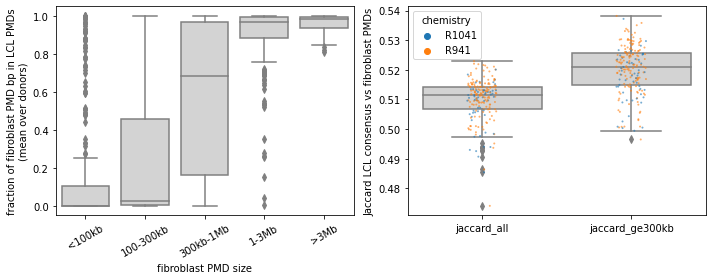

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=fib, x='size_class', y='mean_frac_covered', ax=axes[0], color='lightgray')
axes[0].set_ylabel('fraction of fibroblast PMD bp in LCL PMDs\n(mean over donors)')
axes[0].set_xlabel('fibroblast PMD size')
axes[0].tick_params(axis='x', rotation=30)
m = jac.melt(id_vars=['sample', 'chemistry'], value_vars=['jaccard_all', 'jaccard_ge300kb'])
sns.boxplot(data=m, x='variable', y='value', ax=axes[1], color='lightgray')
sns.stripplot(data=m, x='variable', y='value', hue='chemistry', ax=axes[1], size=2, alpha=0.6)
axes[1].set_ylabel('Jaccard LCL consensus vs fibroblast PMDs')
axes[1].set_xlabel('')
plt.tight_layout()
plt.savefig(f'{figdir}/qc12_fib_lcl_pmd_overlap_by_size.png', dpi=150)

### where does each donor sit on the domain-depth continuum

In [15]:
dm = pd.read_csv(f'{projdir}/results/meth_bins/donor_metrics.tsv', sep='\t')
dm.head()

,sample,chemistry,superpopulation,global_meth,frac_cpg_in_pmd,pmd_burden_bp,frac_bins_below_0.5,frac_bins_rel_low,meth_constitutive_domains,meth_never_domain_bins,domain_contrast
0,HG00097,R1041,EUR,0.520791,0.403401,1.550922e+09,0.196346,0.226574,0.532610,0.778194,0.245584
1,HG00099,R941,EUR,0.518563,0.335799,1.322907e+09,0.090726,0.211589,0.591849,0.789830,0.197980
2,HG00126,R1041,EUR,0.529499,0.358318,1.347435e+09,0.087115,0.198689,0.593786,0.782072,0.188286
3,HG00128,R1041,EUR,0.522023,0.444308,1.611503e+09,0.153676,0.227002,0.552431,0.788791,0.236361
4,HG00133,R1041,EUR,0.528512,0.356709,1.391396e+09,0.096075,0.210409,0.585918,0.787096,0.201178


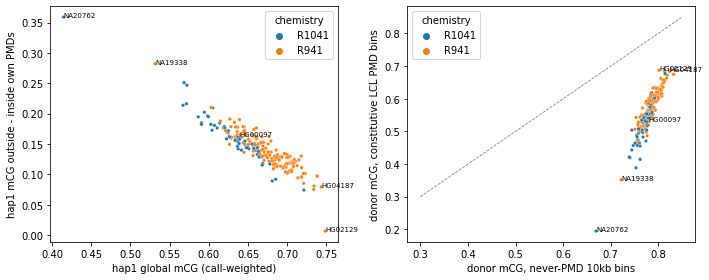

In [16]:
label = ['NA19338', 'NA20762', 'HG04187', 'HG02129', 'HG00097']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
h1 = summ[summ['hap'] == 1]
sns.scatterplot(data=h1, x='global_wmeth', y='contrast', hue='chemistry', s=12, ax=axes[0])
for s in label:
    r = h1[h1['sample'] == s]
    if len(r):
        axes[0].annotate(s, (r['global_wmeth'].iloc[0], r['contrast'].iloc[0]), fontsize=7)
axes[0].set_xlabel('hap1 global mCG (call-weighted)')
axes[0].set_ylabel('hap1 mCG outside - inside own PMDs')
sns.scatterplot(data=dm, x='meth_never_domain_bins', y='meth_constitutive_domains', hue='chemistry', s=12, ax=axes[1])
for s in label:
    r = dm[dm['sample'] == s]
    if len(r):
        axes[1].annotate(s, (r['meth_never_domain_bins'].iloc[0], r['meth_constitutive_domains'].iloc[0]), fontsize=7)
lims = [0.3, 0.85]
axes[1].plot(lims, lims, ls='--', c='gray', lw=0.8)
axes[1].set_xlabel('donor mCG, never-PMD 10kb bins')
axes[1].set_ylabel('donor mCG, constitutive LCL PMD bins')
plt.tight_layout()
plt.savefig(f'{figdir}/qc12_domain_depth_continuum.png', dpi=150)

In [17]:
dm.sort_values('domain_contrast')[['sample', 'chemistry', 'global_meth', 'meth_constitutive_domains', 'meth_never_domain_bins', 'domain_contrast']].head()

,sample,chemistry,global_meth,meth_constitutive_domains,meth_never_domain_bins,domain_contrast
77,HG02129,R941,0.527852,0.687232,0.801348,0.114116
58,HG01928,R941,0.527065,0.685746,0.813211,0.127465
179,NA19700,R1041,0.527685,0.677093,0.814155,0.137063
152,HG04187,R941,0.535145,0.683434,0.823756,0.140322
36,HG01081,R941,0.516352,0.661959,0.805404,0.143446


In [18]:
dm.sort_values('domain_contrast')[['sample', 'chemistry', 'global_meth', 'meth_constitutive_domains', 'meth_never_domain_bins', 'domain_contrast']].tail()

,sample,chemistry,global_meth,meth_constitutive_domains,meth_never_domain_bins,domain_contrast
130,HG03521,R1041,0.514892,0.419287,0.740451,0.321164
98,HG02583,R1041,0.513337,0.414303,0.761961,0.347659
11,HG00290,R1041,0.526730,0.388619,0.753071,0.364452
174,NA19338,R941,0.519506,0.351970,0.721845,0.369875
187,NA20762,R1041,0.419075,0.194616,0.669198,0.474582


### PMD metagene profiles (A01f)

In [19]:
files = sorted(glob.glob(f'{projdir}/results/pmd_metagene/per_hap/*.npz'))
sets = ['lcl_constitutive_ge300kb', 'fibroblast', 'fibroblast_ge300kb', 'NA19338_consensus_ge300kb', 'HG04187_consensus_ge300kb']

def load_profile(f):
    z = np.load(f)
    tag = f.split('/')[-1][:-4]
    return tag, {k: np.nanmean(z[k].astype(float), axis=0) for k in sets}

with ProcessPoolExecutor(10) as ex:
    profs = dict(ex.map(load_profile, files))
len(profs)

402

In [20]:
rows = []
for tag, d in profs.items():
    s, h = tag.rsplit('_hap', 1)
    for k, v in d.items():
        for i, x in enumerate(v):
            rows.append((s, int(h), k, i, x))
meta = pd.DataFrame(rows, columns=['sample', 'hap', 'set', 'bin', 'mcg'])
meta = meta.merge(summ[['sample', 'hap', 'global_wmeth', 'chemistry']], on=['sample', 'hap'], how='left')
meta.head()

,sample,hap,set,bin,mcg,global_wmeth,chemistry
0,HG00097,1,lcl_constitutive_ge300kb,0,71.192320,0.639523,R1041
1,HG00097,1,lcl_constitutive_ge300kb,1,70.787079,0.639523,R1041
2,HG00097,1,lcl_constitutive_ge300kb,2,70.714529,0.639523,R1041
3,HG00097,1,lcl_constitutive_ge300kb,3,70.637411,0.639523,R1041
4,HG00097,1,lcl_constitutive_ge300kb,4,70.212432,0.639523,R1041


In [21]:
meta.shape

(160800, 7)

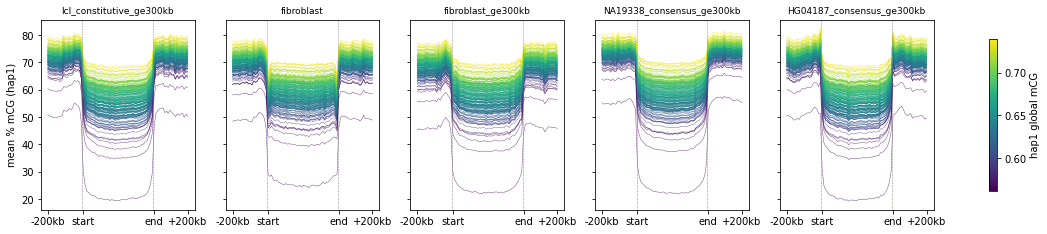

In [22]:
fig, axes = plt.subplots(1, len(sets), figsize=(4 * len(sets), 3.5), sharey=True)
norm = plt.Normalize(meta['global_wmeth'].quantile(0.01), meta['global_wmeth'].quantile(0.99))
cmap = plt.cm.viridis
for ax, k in zip(axes, sets):
    sub = meta[(meta['set'] == k) & (meta['hap'] == 1)]
    for s, g in sub.groupby('sample'):
        ax.plot(g['bin'], g['mcg'], color=cmap(norm(g['global_wmeth'].iloc[0])), lw=0.5, alpha=0.7)
    ax.axvline(19.5, c='gray', lw=0.5, ls='--')
    ax.axvline(59.5, c='gray', lw=0.5, ls='--')
    ax.set_xticks([0, 20, 60, 79])
    ax.set_xticklabels(['-200kb', 'start', 'end', '+200kb'])
    ax.set_title(k, fontsize=9)
axes[0].set_ylabel('mean % mCG (hap1)')
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=axes, label='hap1 global mCG', shrink=0.8)
plt.savefig(f'{figdir}/qc12_pmd_metagene_by_global_mcg.png', dpi=150, bbox_inches='tight')

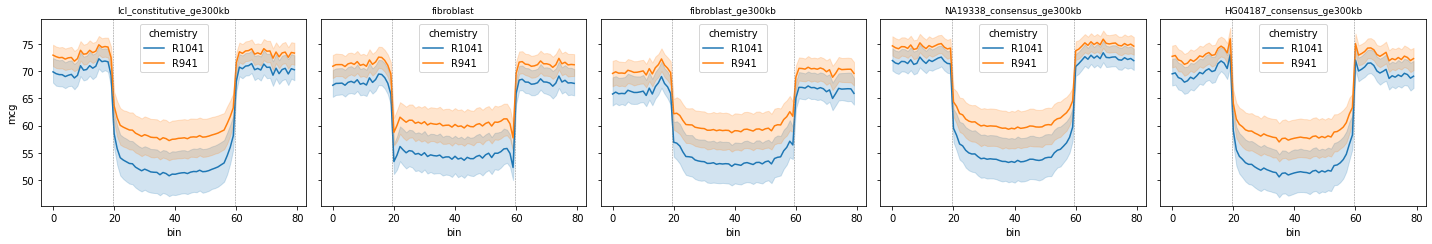

In [23]:
fig, axes = plt.subplots(1, len(sets), figsize=(4 * len(sets), 3.5), sharey=True)
for ax, k in zip(axes, sets):
    sub = meta[meta['set'] == k]
    sns.lineplot(data=sub, x='bin', y='mcg', hue='chemistry', ax=ax, errorbar=('pi', 50))
    ax.axvline(19.5, c='gray', lw=0.5, ls='--')
    ax.axvline(59.5, c='gray', lw=0.5, ls='--')
    ax.set_title(k, fontsize=9)
plt.tight_layout()
plt.savefig(f'{figdir}/qc12_pmd_metagene_by_chemistry.png', dpi=150)

In [24]:
# body depth per haplotype: flank mean minus body mean, per set
depth = meta.assign(part=np.where(meta['bin'].between(20, 59), 'body', 'flank')).groupby(
    ['sample', 'hap', 'set', 'part', 'global_wmeth', 'chemistry'])['mcg'].mean().unstack('part').reset_index()
depth['flank_minus_body'] = depth['flank'] - depth['body']
depth.groupby('set')['flank_minus_body'].describe()

,count,mean,std,min,25%,50%,75%,max
set,,,,,,,,
HG04187_consensus_ge300kb,402.0,15.072066,2.971613,8.246286,12.822958,14.917654,16.808516,29.939593
NA19338_consensus_ge300kb,402.0,14.933753,3.187203,7.971162,12.626601,14.740860,16.689801,32.045500
fibroblast,402.0,11.687813,2.127298,6.884774,10.114994,11.535789,12.822516,23.354098
fibroblast_ge300kb,402.0,10.928116,2.206742,5.933257,9.266923,10.781347,12.161830,22.873504
lcl_constitutive_ge300kb,402.0,15.435421,3.060138,8.295456,13.027019,15.254965,17.238849,30.613051


### write outputs

In [25]:
jac.to_csv(f'{outdir}/lcl_fib_jaccard_by_size.tsv', sep='\t', index=False)
fib.drop(columns=[]).to_csv(f'{outdir}/fib_pmd_coverage_by_lcl.tsv', sep='\t', index=False)
bysize.to_csv(f'{outdir}/fib_pmd_coverage_by_size_class.tsv', sep='\t')
meta.to_csv(f'{outdir}/pmd_metagene_long.tsv.gz', sep='\t', index=False)
depth.to_csv(f'{outdir}/pmd_metagene_body_depth.tsv', sep='\t', index=False)

In [26]:
!date

Fri Sep 18 00:28:19 PDT 2026
